In [29]:
import os as os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import LinearRegression
import math
import re
from datetime import datetime
colors = [
    '#1f77b4',  # tab:blue
    '#ff7f0e',  # tab:orange
    '#2ca02c',  # tab:green
    '#d62728',  # tab:red
    '#9467bd',  # tab:purple
    '#8c564b',  # tab:brown
    '#e377c2',  # tab:pink
    '#7f7f7f',  # tab:gray
    '#bcbd22',  # tab:olive
    '#17becf'   # tab:cyan
]

In [30]:
def find_max(x, y, start, end):
    ma = -1
    xx = -1
    yy = -1
    for i in range(len(x)):
        if x[i] >= start and x[i] <= end:
            if y[i] > ma:
                ma = y[i]
                xx = x[i]
                yy = y[i]
    return xx, yy
                
def find_min(x, y, start, end):
    mi = 10000
    xx = -1
    yy = -1
    for i in range(len(x)):
        if x[i] >= start and x[i] <= end:
            if y[i] < mi:
                mi = y[i]
                xx = x[i]
                yy = y[i]
    return xx, yy

def find_y(x,y,xi):
    for i in range(len(x)):
        if x[i] == xi:
            return y[i]
    return -1

def separater(x, y, left, right):
    upperx = []
    lowerx = []
    uppery = []
    lowery = []
    
    x = x.tolist()  # Convert Int64Index to list
    y = y.tolist()  # Convert Int64Index to list
    
    boundary_l = x.index(left)
    boundary_r = x.index(right)
    
    if boundary_r < boundary_l:
        upperx = x[boundary_l:] + x[:boundary_r+1]
        uppery = y[boundary_l:] + y[:boundary_r+1]
        lowerx = x[boundary_r:boundary_l+1]
        lowery = y[boundary_r:boundary_l+1]
    else:
        upperx = x[boundary_l:boundary_r+1]
        uppery = y[boundary_l:boundary_r+1]
        lowerx = x[boundary_r:] + x[:boundary_l+1]
        lowery = y[boundary_r:] + y[:boundary_l+1]
    
    return upperx, lowerx, uppery, lowery

def Search_scan_rate(filename):
    match = re.search(r'(\d+)mVs', filename)
    if match:
        return int(match.group(1))
    else:
        # Handle files without RPM values
        return -1  # You can use any default value or treatment
    
def Milad(filename):
    match = re.search(r'PFOS_(\d+)', filename)
    if match:
        return int(match.group(1))
    else:
        # Handle files without RPM values
        return -1  # You can use any default value or treatment
    
def read_ec_lab_file(file_path, encoding='utf-8'):
    with open(file_path, 'r', encoding=encoding) as file:
        lines = file.readlines()

    # Determine the number of header lines
    num_header_lines = 56  # As per the given pattern

    # Extract the data lines (skipping the header)
    data_lines = lines[num_header_lines:]

    # Create a list to store the extracted data
    data = []

    for line in data_lines:
        if line.strip():  # Ignore empty lines
            parts = line.split()
            if len(parts) == 2:
                ewe, i_mA = parts
                data.append((float(ewe), float(i_mA)))

    # Convert to DataFrame
    df = pd.DataFrame(data, columns=['Ewe/V', '<I>/mA'])
    return df

def read_auto_lab_file(file):
    df = pd.read_excel(file, sheet_name='Sheet1', engine='openpyxl')
    return df

def create_file_template_CV(file_name):
    # Use a regular expression to find the rpm part
    pattern = r'(\d+)mVs'
    
    # Replace the numeric rpm part with a placeholder for formatting later
    template = re.sub(pattern, '%dmVs', file_name)
    
    return template

def make_color_darker(color, factor):
    # Extract the RGB components from the hex color string
    r, g, b = int(color[1:3], 16), int(color[3:5], 16), int(color[5:7], 16)
    
    # Apply the darkening factor to each component
    r = max(0, int(r * factor))
    g = max(0, int(g * factor))
    b = max(0, int(b * factor))
    
    # Convert the darkened RGB values back to a hex color string
    return f'#{r:02x}{g:02x}{b:02x}'

def special_log(a_list):
    a_list_special_log = np.zeros_like(a_list)  # Initialize log array with zeros

    for idx, value in enumerate(a_list):
        if value > 0:
            a_list_special_log[idx] = np.log10(value)
        elif value < 0:
            a_list_special_log[idx] = np.log10(-value)
        else:  # value == 0
            a_list_special_log[idx] = 0

    return a_list_special_log


def special_ln(a_list):
    a_list_special_ln = np.zeros_like(a_list)  # Initialize log array with zeros

    for idx, value in enumerate(a_list):
        if value > 0:
            a_list_special_ln[idx] = np.log(value)
        elif value < 0:
            a_list_special_ln[idx] = np.log(-value)
        else:  # value == 0
            a_list_special_ln[idx] = 0

    return a_list_special_ln

In [31]:
## file location and device input
# device now supporting for Autolab and EClab only
device = f'Autolab'
folder_name = "01112023 CV DMAB"

filepath="C:\\Users\\Grant Xue\\OneDrive\\Desktop\\" + folder_name
result_path = 'C:\\Users\\Grant Xue\\OneDrive\\Desktop\\J. Electroanalytical Chemistry 2023\\images_300DPI'
files = os.listdir(filepath)
files = sorted(files, key = Search_scan_rate)
print("\033[1mFiles in Folder:\033[0m")
for file in files:
    print(file)
    
if device == 'Autolab':
    Filter_files = [file for file in files if file.endswith('.xlsx')]
elif device == 'EClab':
    Filter_files = [file for file in sorted_files if file.endswith('.txt')]
else:
    print('device not found in library')
    
print("\n\033[1mFilter_files:\033[0m")
for file in Filter_files:
    print(file)

file_template = os.path.splitext(create_file_template_CV(Filter_files[0]))[0]

print('\n\033[1mCreated variable:\033[0m')
data_list = []
for file in Filter_files:
    scan_rate = Search_scan_rate(file)
    df = read_auto_lab_file(os.path.join(filepath, file))
    var_name = file_template % scan_rate
    globals()[var_name] = df
    data_list.append(var_name)
    print(var_name)

#==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Done:", formatted_time)

Files in Folder:
01112023.pdf
01112023.png
all_50.txt
CV_csv
CV_csv.zip
Sim_k0.txt
Sim_k_1-10.txt
G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV.xlsx
G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV.txt
G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV.xlsx

Filter_files:
G_P_KOH40.0032g

G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV


C:\Software\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


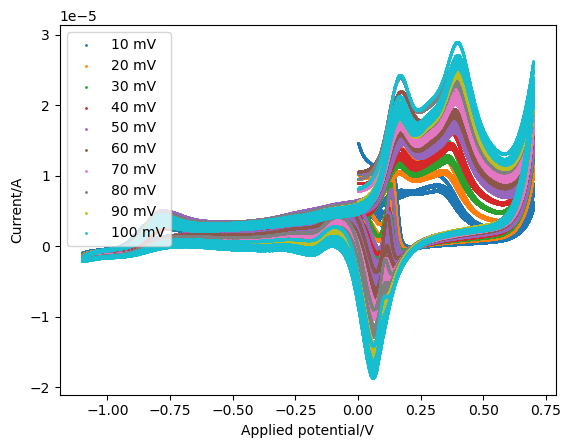

G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV


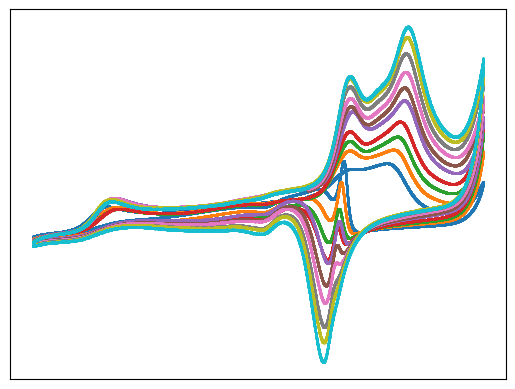

CV_D saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Done: 2025-07-17 16:59:59


In [32]:
# (Function 1)display CV plot
# input showed cycle
cycle = 6

# plot everything
plt.figure()

for var_name in data_list:
    print(var_name)
    df = globals()[var_name]  # Access the DataFrame using the variable name
    U = df['WE(1).Potential (V)']
    I = df['WE(1).Current (A)']
    scan_rate = Search_scan_rate(var_name)  # Extract scan rate from the variable name
    plt.scatter(U, I, label=f'{scan_rate} mV', s=1)

plt.xlabel('Applied potential/V')
plt.ylabel('Current/A')
plt.legend()
plt.show()

# plot certain cycles
plt.figure()

for var_name in data_list:
    print(var_name)
    df = globals()[var_name]  # Access the DataFrame using the variable name
    df = df[df['Scan'] == cycle]
    U = df['WE(1).Potential (V)']
    I = df['WE(1).Current (A)']
    scan_rate = Search_scan_rate(var_name)  # Extract scan rate from the variable name
    plt.scatter(U, I, label=f'{scan_rate} mV', s=1)

# plt.xlabel('Applied potential/V')
# plt.ylabel('Current/A')
plt.xticks([])  # Remove x-axis numbers
plt.yticks([])  # Remove y-axis numbers
# plt.legend(ncol=2)
# Save as high-resolution PNG and Vector PDF
output_name = 'CV_D'
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

#==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Done:", formatted_time)


Figure Set for Peak1:
Going to process the following files:
G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV


G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV


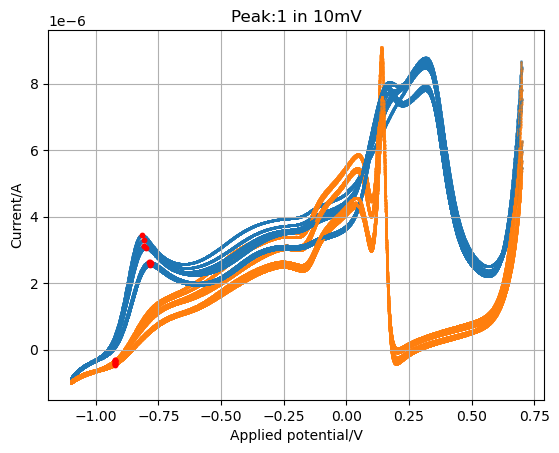

G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV


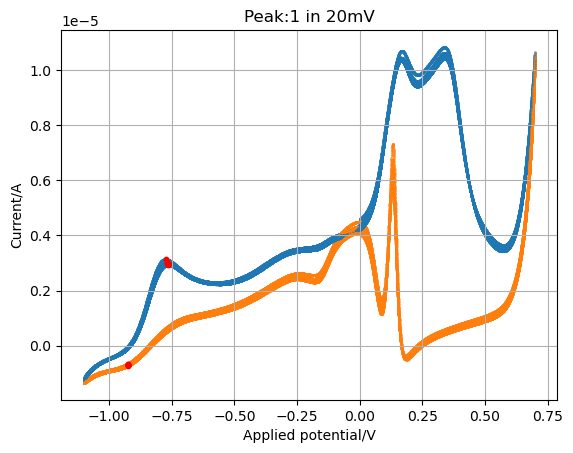

G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV


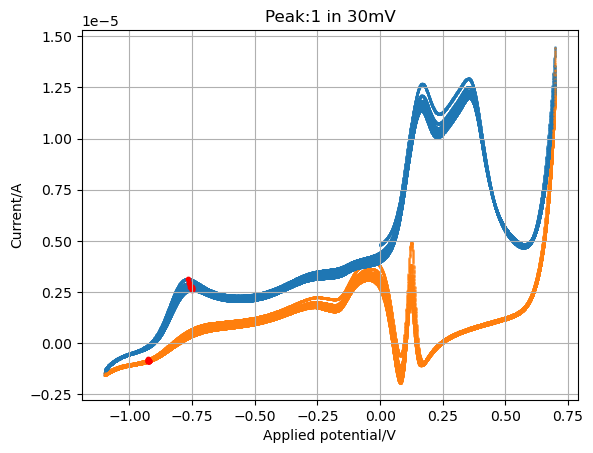

G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV


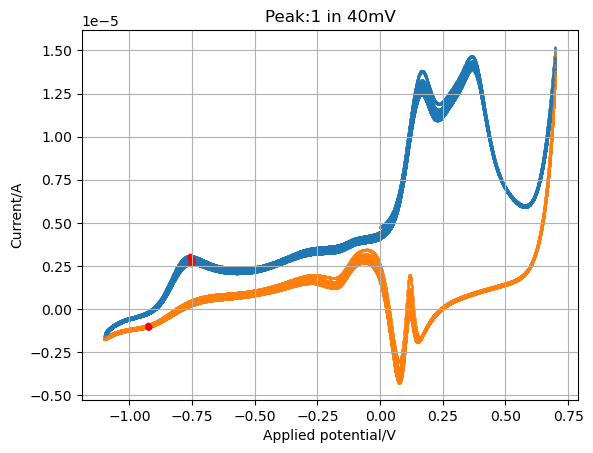

G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV


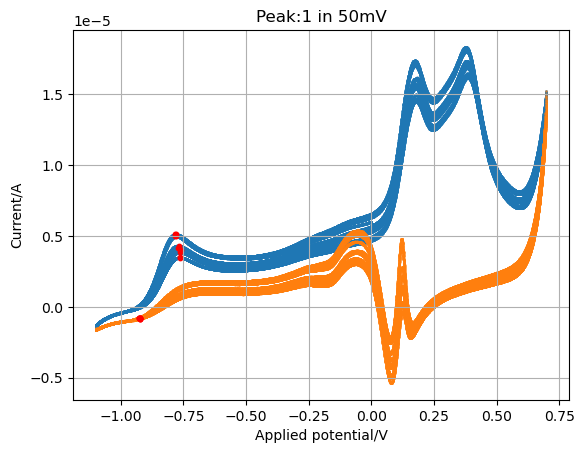

G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV


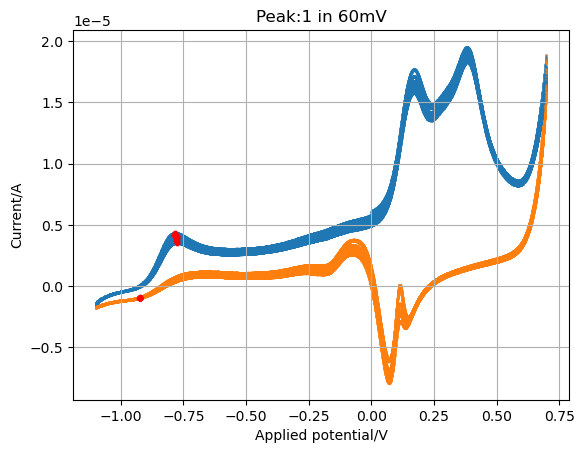

G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV


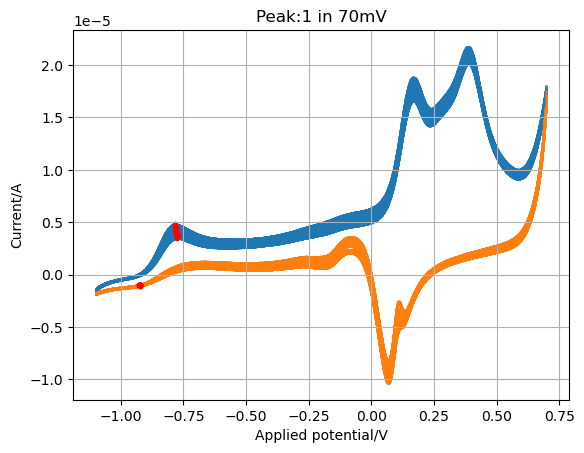

G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV


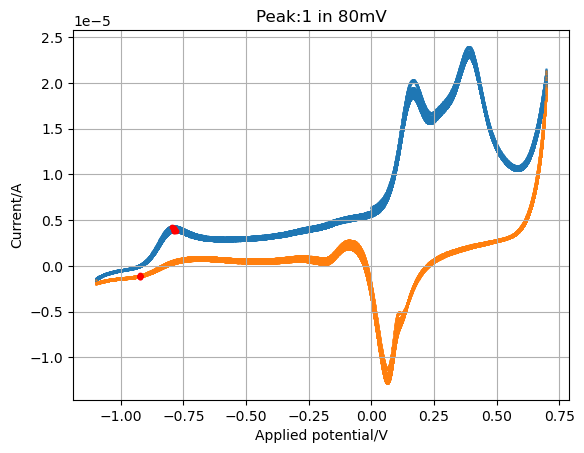

G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV


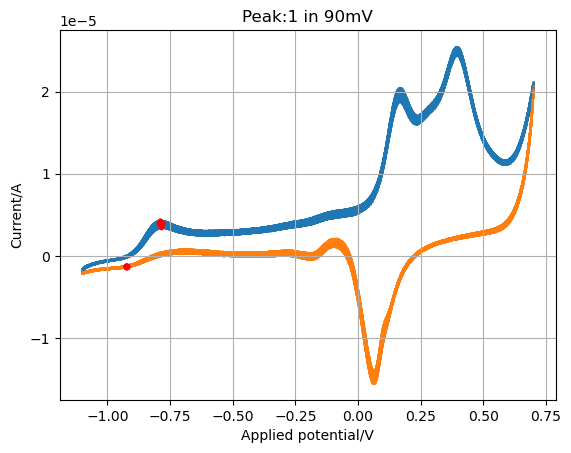

G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV


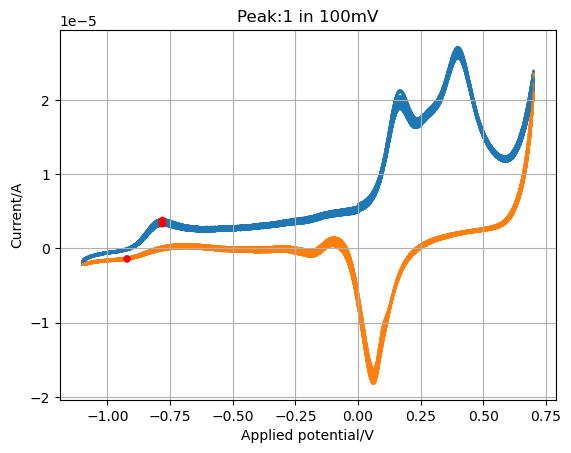


Figure Set for Peak2:
Going to process the following files:
G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV


G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV


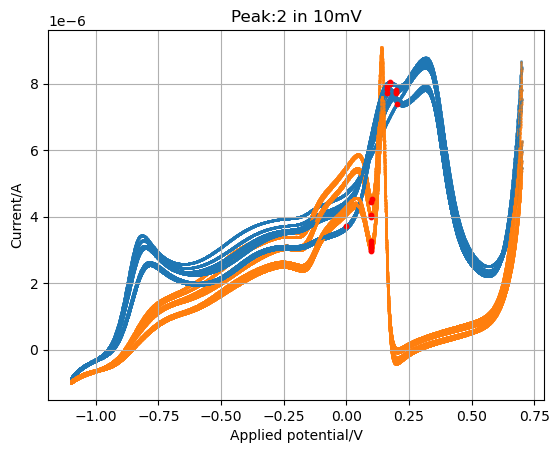

G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV


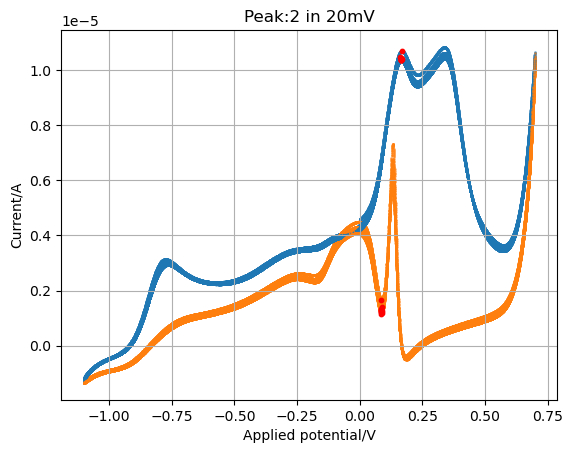

G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV


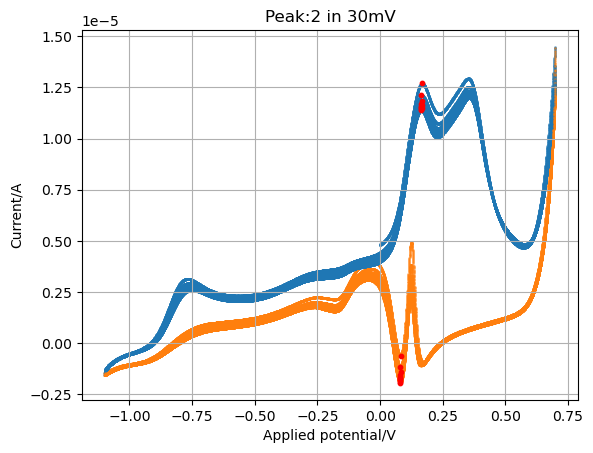

G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV


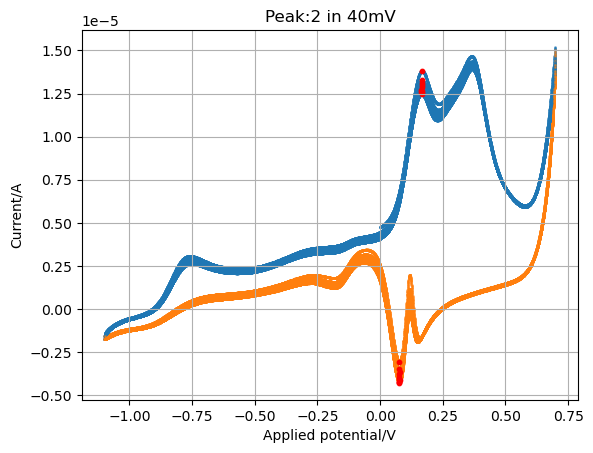

G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV


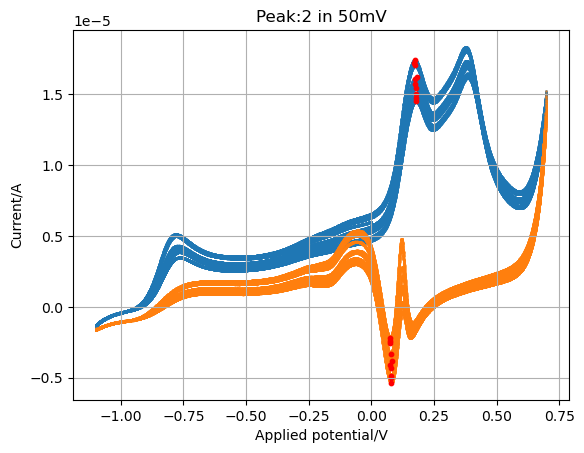

G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV


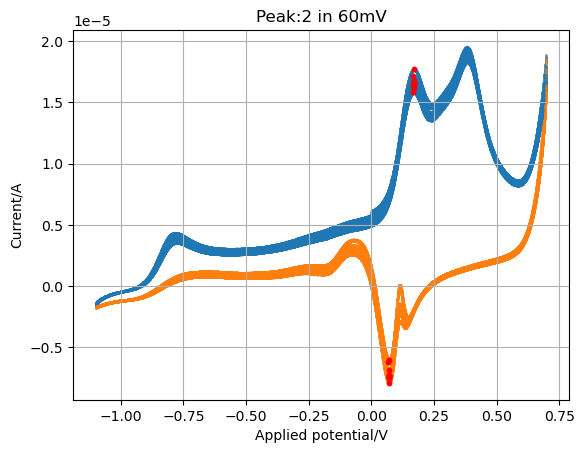

G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV


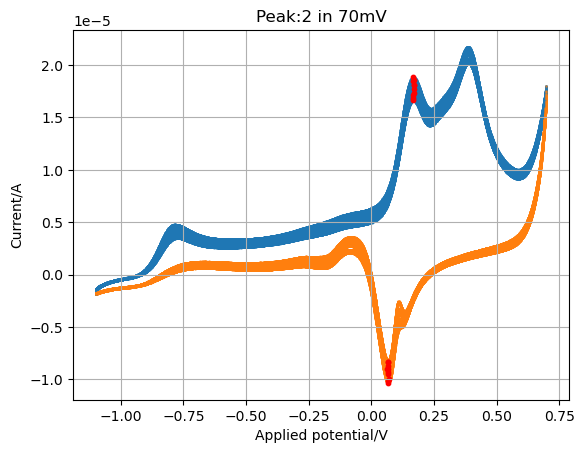

G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV


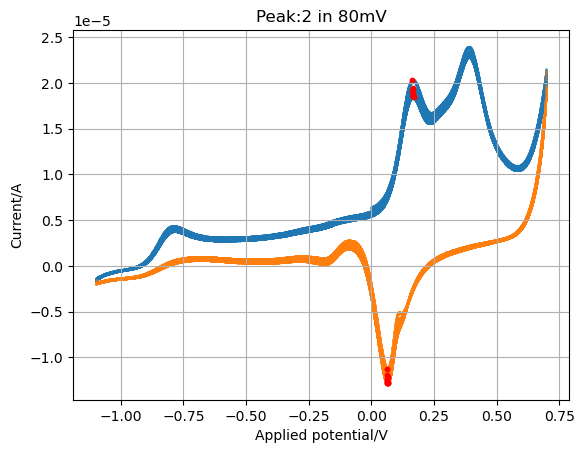

G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV


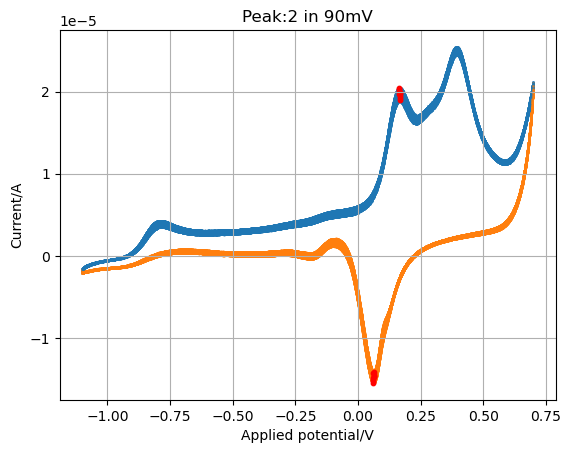

G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV


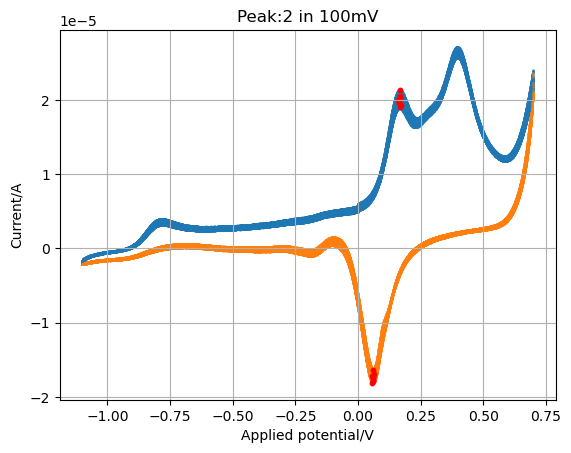


Figure Set for Peak3:
Going to process the following files:
G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV


G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV


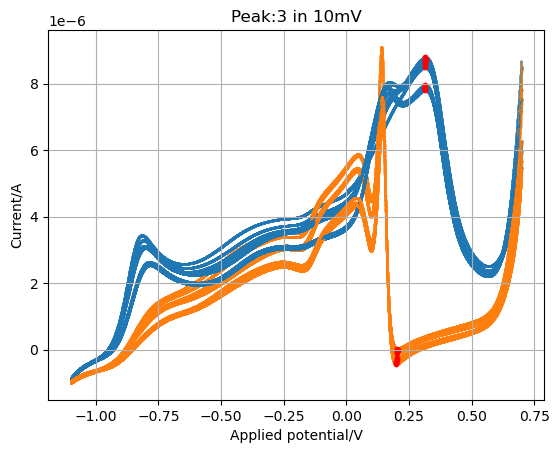

G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV


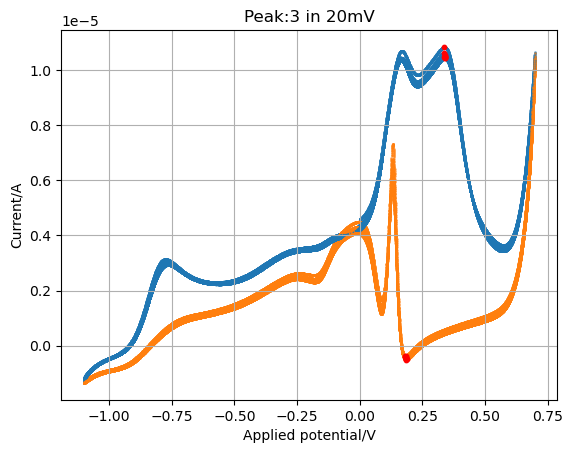

G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV


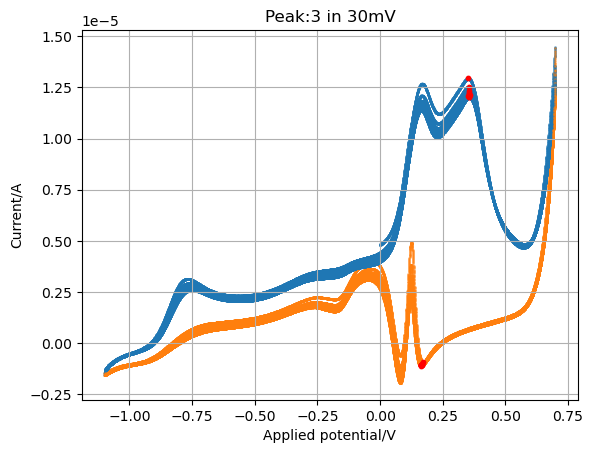

G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV


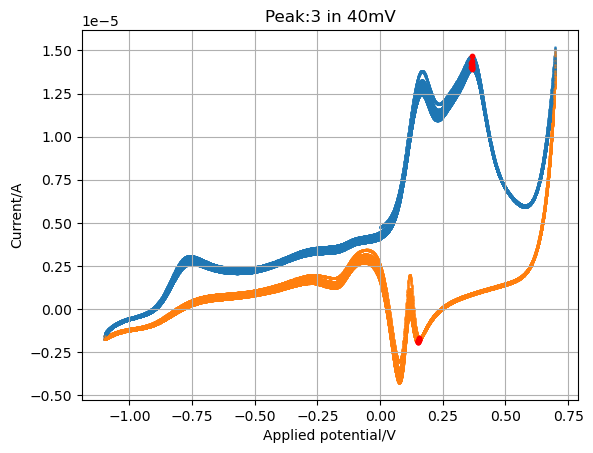

G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV


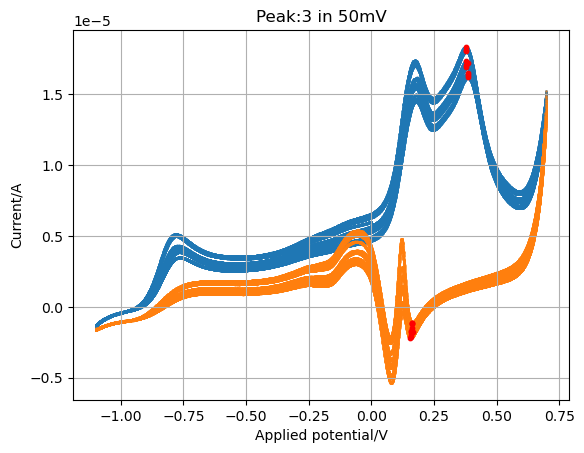

G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV


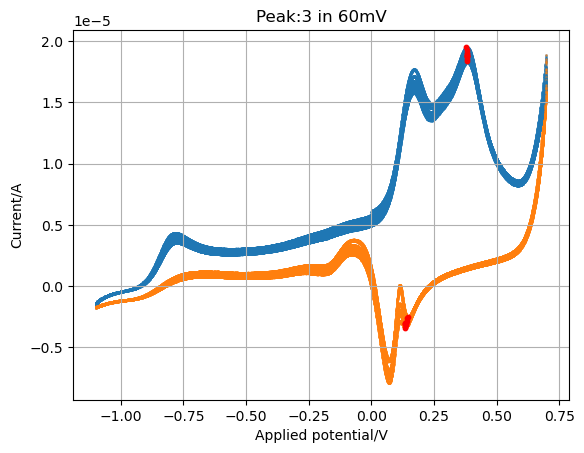

G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV


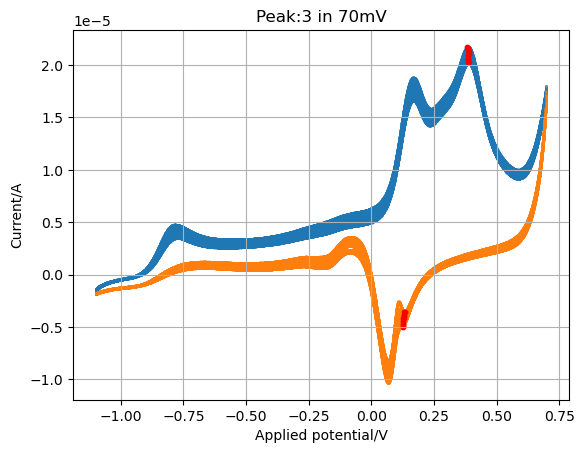

G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV


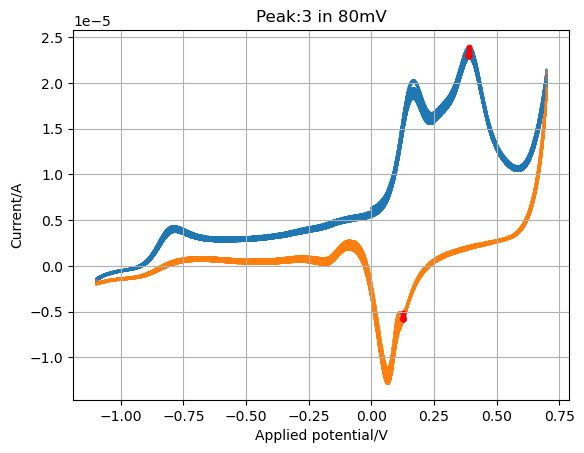

Done: 2025-07-17 17:01:08


In [33]:
## (Function 2) II peak searching module
#input parameter
peak_info = {}
peak_range_ox = [(-1, -0.70),(0, 0.2),(0.25, 0.5)]
peak_range_re = [(-0.925,-0.75),(0.0, 0.125),(0.125, 0.25)]
discard_scan_start = [0,0,0]  # Number of scans to discard from the start
discard_scan_end = [0,0,2]    # Number of scans to discard from the end


# peak_range_ox = [(0, 0.4)]
# peak_range_re = [(0,0.2)]
# discard_scan_start = [0]    # Number of scans to discard from the start
# discard_scan_end = [0]    # Number of scans to discard from the end

cycle_range = range(2, 12)

for z in range(len(peak_range_ox)):
    peak_info[f'Ef{z}'] = []
    peak_info[f'DelE0{z}'] = []
    peak_info[f'Ea{z}'] = []
    peak_info[f'Ec{z}'] = []
    peak_info[f'Ia{z}'] = []
    peak_info[f'Ic{z}'] = []
    peak_info[f'Scan_Rate{z}'] = []

    # Create a new figure for each z loop
    print(f'\n\033[1mFigure Set for Peak{z+1}:\033[0m')
    plt.figure()

    # Determine the slice based on the variable
    selected_data_list = data_list[discard_scan_start[z]:len(data_list) - discard_scan_end[z]]
    print("\033[1mGoing to process the following files:\033[0m")
    for file in selected_data_list:
        print(file)
    print("\n")

    # Find peak position
    for var_name in selected_data_list:
        df = globals()[var_name]
        print(var_name)
        scan_rate = Search_scan_rate(var_name)
        name = str(scan_rate) + "mV"
        
        # Initialize lists for this file
        Ea_j = []
        Ec_j = []
        Ia_j = []
        Ic_j = []

        for i in cycle_range:
            cycle_df = df[df['Scan'] == i]
            
            if cycle_df.empty:
                print(f"Warning: No data found for scan {i} in file {var_name}")
                continue  # Skip this scan if there's no data
                
            Ui = cycle_df['WE(1).Potential (V)']
            Ii = cycle_df['WE(1).Current (A)']
            Ui = np.array(Ui)
            Ii = np.array(Ii)

            # Separate top and bottom
            upperU, lowerU, upperI, lowerI = separater(Ui, Ii, min(Ui), max(Ui))

            # Apply Gaussian filter (optional)
            apply_gaussian_filter = False  # Set to True to apply the filter, False to not apply the filter

            if apply_gaussian_filter:
                smoothed_upperI = gaussian_filter(upperI, sigma=1)
                smoothed_lowerI = gaussian_filter(lowerI, sigma=1)
            else:
                smoothed_upperI = upperI
                smoothed_lowerI = lowerI

            # Input range of first peak
            top_x, top_y = find_max(upperU, smoothed_upperI, peak_range_ox[z][0], peak_range_ox[z][1])
            bottom_x, bottom_y = find_min(lowerU, smoothed_lowerI, peak_range_re[z][0], peak_range_re[z][1])
            DelE02i = top_x - bottom_x
            Ef2i = (top_x + bottom_x) / 2

            peak_info[f'Ea{z}'].append(top_x)
            Ea_j.append(top_x)
            peak_info[f'Ia{z}'].append(find_y(upperU, smoothed_upperI, top_x))
            Ia_j.append(find_y(upperU, smoothed_upperI, top_x))
            peak_info[f'Ec{z}'].append(bottom_x)
            Ec_j.append(bottom_x)
            peak_info[f'Ic{z}'].append(find_y(lowerU, smoothed_lowerI, bottom_x))
            Ic_j.append(find_y(lowerU, smoothed_lowerI, bottom_x))

            peak_info[f'DelE0{z}'].append(DelE02i)
            peak_info[f'Ef{z}'].append(Ef2i)

            peak_info[f'Scan_Rate{z}'].append(scan_rate)

            plt.scatter(upperU, smoothed_upperI, s=1, alpha=0.5,c ='#1f77b4')
            plt.scatter(lowerU, smoothed_lowerI, s=1, alpha=0.5,c ='#ff7f0e')

        plt.scatter(Ea_j, Ia_j, s=10, c='r')  # Second peak data in red
        plt.scatter(Ec_j, Ic_j, s=10, c='r')

        plt.xlabel('Applied potential/V')
        plt.ylabel('Current/A')
        plt.title(f'Peak:{z+1} in {name}')
        plt.grid()
        plt.show()
        
#==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Done:", formatted_time)

In [34]:
def show_info(peak_info, n=5):
    for key, values in peak_info.items():
        # Check if the list is shorter than n, if so, adjust n to the length of the list
        display_length = min(len(values), n)
        print(f'{key}: {[len(values)]} {values[:display_length]}')

# Call the function to print the head of peak_info
show_info(peak_info)

# Dictionary to store the mean values of Ef
mean_Ef = {}

for i in range(len(peak_range_ox)):
    Ef = np.mean(peak_info[f'Ef{i}'])
    mean_Ef[f'Ef{i+1}'] = Ef

# Print the results
for key, value in mean_Ef.items():
    print(f"{key}: {value}")

Ef0: [100] [-0.870819091796875, -0.865936279296875, -0.8660888671875, -0.865325927734375, -0.862579345703125]
DelE00: [100] [0.10772705078125, 0.11688232421875, 0.1177978515625, 0.11932373046875, 0.12359619140625]
Ea0: [100] [-0.81695556640625, -0.8074951171875, -0.80718994140625, -0.8056640625, -0.80078125]
Ec0: [100] [-0.9246826171875, -0.92437744140625, -0.92498779296875, -0.92498779296875, -0.92437744140625]
Ia0: [100] [3.44085693359375e-06, 3.2931518554687515e-06, 3.1234741210937503e-06, 3.1213378906250007e-06, 3.0661010742187497e-06]
Ic0: [100] [-3.353881835937503e-07, -3.125000000000003e-07, -3.2135009765625056e-07, -3.2989501953124974e-07, -3.3477783203124944e-07]
Scan_Rate0: [100] [10, 10, 10, 10, 10]
Ef1: [100] [0.1500091552734375, 0.1497650146484375, 0.1490020751953125, 0.1479644775390625, 0.1366119384765625]
DelE01: [100] [0.099945068359375, 0.099700927734375, 0.100799560546875, 0.099456787109375, 0.076934814453125]
Ea1: [100] [0.199981689453125, 0.199615478515625, 0.199401

G_P_KOH40.0032gL_DMAB0.0475gL_10mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_30mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_40mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_50mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_60mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_70mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_80mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_90mVs_CV
G_P_KOH40.0032gL_DMAB0.0475gL_100mVs_CV


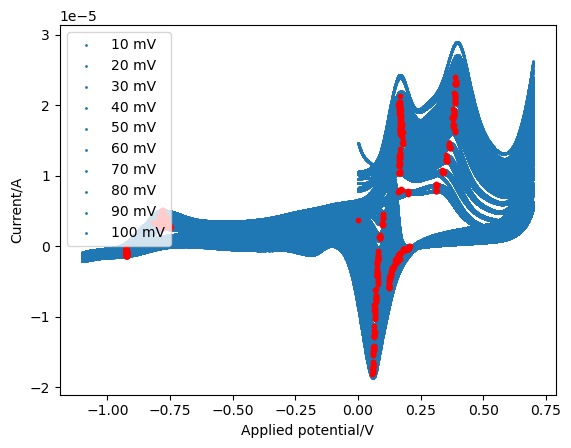

['G_P_KOH40.0032gL_DMAB0.0475gL_20mVs_CV']


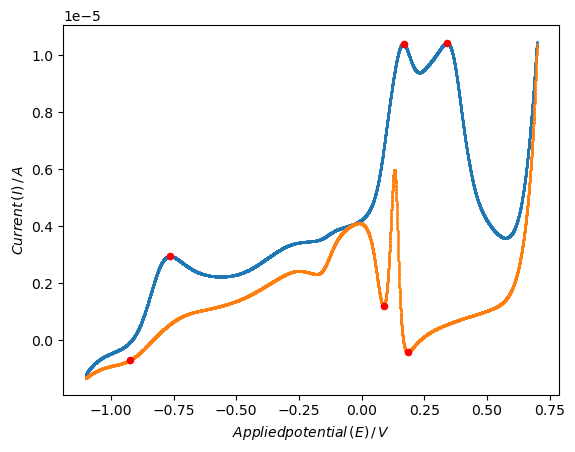

CVPS_D saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Done: 2025-07-17 17:02:39


In [35]:
## (Function 2) Calculattion and display result of Ep and E0
## 2.2 Display moudle
example_scan = 20
example_cycle = 9

## show all searched peaks on the CV plot figure
plt.figure()
# Plot the CV data
for data_i in data_list:
    df = globals()[data_i]  # Access the DataFrame using the variable name
    print(data_i)
    U = df['WE(1).Potential (V)']
    I = df['WE(1).Current (A)']
    scan_rate = Search_scan_rate(data_i)  # Extract scan rate from the variable name
    plt.scatter(U, I, label=f'{scan_rate} mV', s=1, c ='#1f77b4')

# Plot the peak information
for i in range(len(peak_range_ox)):
    plt_data_Ea = peak_info[f'Ea{i}']
    plt_data_Ec = peak_info[f'Ec{i}']
    plt_data_Ia = peak_info[f'Ia{i}']
    plt_data_Ic = peak_info[f'Ic{i}']    
    plt.scatter(plt_data_Ea, plt_data_Ia, s=10, c='r')  
    plt.scatter(plt_data_Ec, plt_data_Ic, s=10, c='r')  

plt.xlabel('Applied potential/V')
plt.ylabel('Current/A')
plt.legend()
plt.show()


search_key = str(example_scan) + "mV"
# Find all names containing "10mVs"
matching_data = [name for name in data_list if search_key in name]
print(matching_data)
df = globals()[matching_data[0]]
df = df[df['Scan'] == example_cycle]
U = df['WE(1).Potential (V)']
I = df['WE(1).Current (A)']

plt.figure()

# Separate top and bottom
upperU, lowerU, upperI, lowerI = separater(U, I, min(U), max(U))

if apply_gaussian_filter:
    smoothed_upperI = gaussian_filter(upperI, sigma=1)
    smoothed_lowerI = gaussian_filter(lowerI, sigma=1)
else:
    smoothed_upperI = upperI
    smoothed_lowerI = lowerI

plt.scatter(upperU,smoothed_upperI,s=1,c ='#1f77b4')
plt.scatter(lowerU,smoothed_lowerI,s=1,c ='#ff7f0e')

for z in range(len(peak_range_ox)):
    top_x, top_y = find_max(upperU, smoothed_upperI, peak_range_ox[z][0], peak_range_ox[z][1])
    bottom_x, bottom_y = find_min(lowerU, smoothed_lowerI, peak_range_re[z][0], peak_range_re[z][1])
    plt.scatter(top_x, top_y, s=20, c = 'r')
    plt.scatter(bottom_x, bottom_y, s=20, c = 'r')
plt.xlabel('$Applied potential\,(E)\,/\,V$')
plt.ylabel('$Current\,(I)\,/\,A$')
# Save as high-resolution PNG and Vector PDF
output_name = 'CVPS_D'
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

#==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Done:", formatted_time)

Electrode Surface Area: 0.07068583470577035
Start: 2025-06-30 12:35:37


IndexError: list index out of range

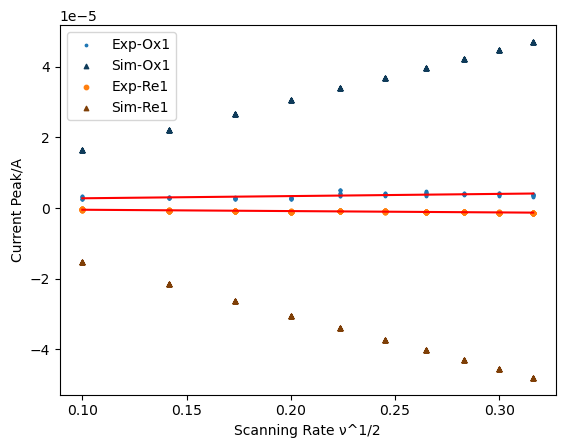

In [9]:
## (Function 3) 3.1 Randles-Sevcik analysis module 

# input calculate parameter
n = 1 # number of electron transfer
C = 0.004e-3 # initial concertration in mol/cm3
T = 298.15 # temperature in K

D_sim_ox = [3.5e-06]
D_sim_re = [4e-06]

# Diameter in cm
electrode_dia = 0.3 # electorde diameter in cm 
A_Real = np.pi * (electrode_dia/2)**2
print('Electrode Surface Area:',A_Real)

# ==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Start:", formatted_time)
# constant number don't change
F = 96485.33212
R = 8.314462618

# Randles–Ševčík plot sprt scan_rate vs Ipeak
D_cal=[]
D_ox = []
D_re = []
plt.figure()

for i in range(len(peak_range_ox)):
    
    scan_rate_05 = ((np.array(peak_info[f'Scan_Rate{i}']))/1000)**0.5
    scan_rate = np.array(peak_info[f'Scan_Rate{i}'])/1000

    La = LinearRegression().fit(np.array(scan_rate_05).reshape(-1, 1), np.array(peak_info[f'Ia{i}']).reshape(-1, 1))
    Ia = La.intercept_[0]
    Sa = La.coef_[0][0]

    Lc = LinearRegression().fit(np.array(scan_rate_05).reshape(-1, 1), np.array(peak_info[f'Ic{i}']).reshape(-1, 1))
    Ic = Lc.intercept_[0]
    Sc = Lc.coef_[0][0]
    
    Ia_sim = 0.4463 * (n * F * C * A_Real * ((n * F * scan_rate * D_sim_ox[i]) / (R * T)) ** 0.5) + Ia
    Ic_sim = -0.4463 * (n * F * C * A_Real * ((n * F * scan_rate * D_sim_re[i]) / (R * T)) ** 0.5) + Ic

    sim_x = np.linspace(min(scan_rate_05), max(scan_rate_05), 100)
    sim_ya = Sa * sim_x + Ia
    sim_yc = Sc * sim_x + Ic

    D_cala = (Sa/(0.446*n*F*C*A_Real*((n*F)/(R*T))**0.5))**2
    D_calc = (Sc/(0.446*n*F*C*A_Real*((n*F)/(R*T))**0.5))**2

    D_cal.append((D_cala,D_calc))
    D_ox.append(D_cala)
    D_re.append(D_calc)
    
    # plot oxidation peaks
    darker_color = make_color_darker(colors[i], 0.5)
    plt.scatter(scan_rate_05,peak_info[f'Ia{i}'],label=f'Exp-Ox{i+1}',s=3, color=colors[i])
    plt.scatter(scan_rate_05,Ia_sim,label=f'Sim-Ox{i+1}',s=10, marker='^', color = darker_color)
    plt.plot(sim_x, sim_ya, color='red')
    plt.xlabel('Scanning Rate ν^1/2')
    plt.ylabel('Current Peak/A')
    plt.legend()
#     plt.grid()
#     plt.show()  
    
    # plot reduction peaks
    darker_color_2 = make_color_darker(colors[i+1], 0.5)
    plt.scatter(scan_rate_05,peak_info[f'Ic{i}'],label=f'Exp-Re{i+1}',s=10, color=colors[i+1])
    plt.scatter(scan_rate_05,Ic_sim,label=f'Sim-Re{i+1}',s=10, marker='^', color = darker_color_2)
    plt.plot(sim_x, sim_yc, color='red')
    plt.xlabel('Scanning Rate ν^1/2')
    plt.ylabel('Current Peak/A')
    plt.legend()
# #     plt.grid()
# Save as high-resolution PNG and Vector PDF
output_name = 'RC_Fe'
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show() 
print(f"{output_name} saved in {result_path}")

print('D_cal:', D_cal)
print('D_ox:', D_ox)
print('D_re:', D_re)

Electrode Surface Area: 0.020106192982974676
Start: 2025-07-17 13:27:23


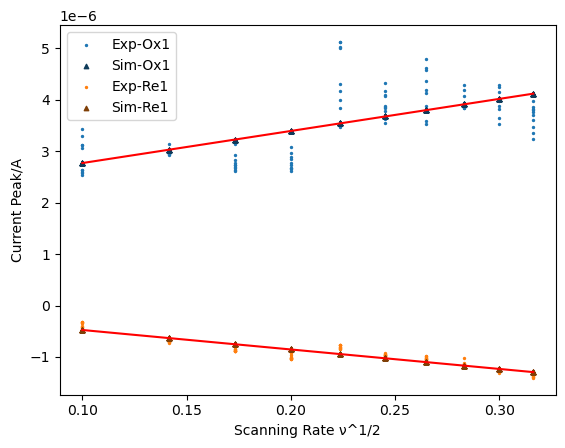

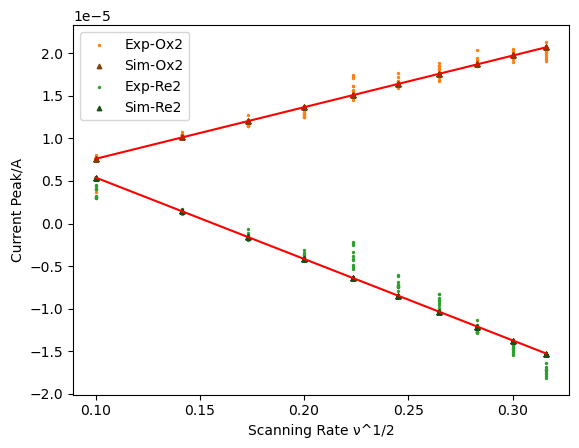

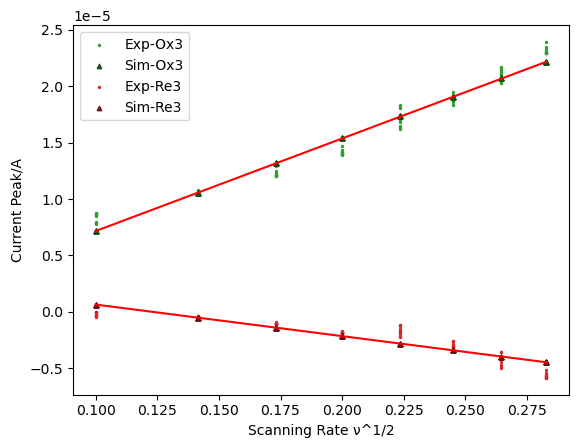

D_cal: [(2.057956336878893e-06, 7.582089066397869e-07), (0.0001939368414955827, 0.000482700516353804), (0.0003564145721954786, 4.1429403958224434e-05)]


In [12]:
## (Function 3) 3.2 Randles-Sevcik analysis module mechnism verify moudle

# input calculate parameter
n = 1 # number of electron transfer
C = 0.000806e-3 # initial concertration in mol/cm3
T = 298.15 # temperature in K
# D in (cm²/s)
D_ox = [2.057956336878893e-06, 0.0001939368414955827, 0.0003564145721954786]
D_re = [7.582089066397869e-07, 0.000482700516353804, 4.1429403958224434e-05]
    
# D_ox: [8e-06]
# D_re: [8e-06]
    
# Diameter in cm
electrode_dia = 0.16 # electorde diameter in cm 
A_Real = np.pi * (electrode_dia/2)**2
print('Electrode Surface Area:',A_Real)

# ==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Start:", formatted_time)
# constant number don't change
F = 96485.33212
R = 8.314462618

# Randles–Ševčík plot sprt scan_rate vs Ipeak
D_cal=[]
plt.figure()
for i in range(len(D_ox)):
    
    scan_rate_05 = ((np.array(peak_info[f'Scan_Rate{i}']))/1000)**0.5
    scan_rate = np.array(peak_info[f'Scan_Rate{i}'])/1000

    La = LinearRegression().fit(np.array(scan_rate_05).reshape(-1, 1), np.array(peak_info[f'Ia{i}']).reshape(-1, 1))
    Ia = La.intercept_[0]
    Sa = La.coef_[0][0]

    Lc = LinearRegression().fit(np.array(scan_rate_05).reshape(-1, 1), np.array(peak_info[f'Ic{i}']).reshape(-1, 1))
    Ic = Lc.intercept_[0]
    Sc = Lc.coef_[0][0]
    
    Ia_sim = 0.4463 * (n * F * C * A_Real * ((n * F * scan_rate * D_ox[i]) / (R * T)) ** 0.5) + Ia
    Ic_sim = -0.4463 * (n * F * C * A_Real * ((n * F * scan_rate * D_re[i]) / (R * T)) ** 0.5) + Ic

    sim_x = np.linspace(min(scan_rate_05), max(scan_rate_05), 100)
    sim_ya = Sa * sim_x + Ia
    sim_yc = Sc * sim_x + Ic

    D_cala = (Sa/(0.446*n*F*C*A_Real*((n*F)/(R*T))**0.5))**2
    D_calc = (Sc/(0.446*n*F*C*A_Real*((n*F)/(R*T))**0.5))**2

    D_cal.append((D_cala,D_calc))
    
    # plot oxidation peaks
    darker_color = make_color_darker(colors[i], 0.5)
    plt.scatter(scan_rate_05,peak_info[f'Ia{i}'],label=f'Exp-Ox{i+1}',s=2, color=colors[i])
    plt.scatter(scan_rate_05,Ia_sim,label=f'Sim-Ox{i+1}',s=10, marker='^', color = darker_color)
    plt.plot(sim_x, sim_ya, color='red')
#     plt.xlabel('Scanning Rate ν^1/2')
#     plt.ylabel('Current Peak/A')
#     plt.legend()
# #     plt.grid()
# plt.show()  
    
    # plot reduction peaks
    darker_color = make_color_darker(colors[i+1], 0.5)
    plt.scatter(scan_rate_05,peak_info[f'Ic{i}'],label=f'Exp-Re{i+1}',s=2, color= colors[i+1])
    plt.scatter(scan_rate_05,Ic_sim,label=f'Sim-Re{i+1}',s=10, marker='^', color = darker_color)
    plt.plot(sim_x, sim_yc, color='red')
    plt.xlabel('Scanning Rate ν^1/2')
    plt.ylabel('Current Peak/A')
    plt.legend()
#     plt.grid()
    plt.show()  

print('D_cal:', D_cal)

Electrode Surface Area: 0.020106192982974676
Start: 2025-07-17 17:09:54


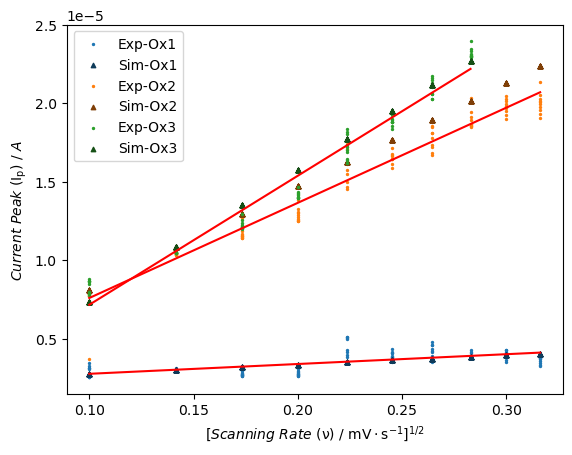

RSSim_D saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
D_cal: [(2.057956336878893e-06, 7.582089066397869e-07), (0.0001939368414955827, 0.000482700516353804), (0.0003564145721954786, 4.1429403958224434e-05)]


In [37]:
## (Function 3) 3.2 Randles-Sevcik analysis module mechnism verify moudle

# input calculate parameter
n = 1 # number of electron transfer
C = 0.000806e-3 # initial concertration in mol/cm3
T = 298.15 # temperature in K
# D in (cm²/s)
D_ox = [2.057956336878893e-06, 0.0001939368414955827, 0.0003564145721954786]
D_re = [7.582089066397869e-07, 0.000482700516353804, 4.1429403958224434e-05]
    
# D_ox: [8e-06]
# D_re: [8e-06]
    
# Diameter in cm
electrode_dia = 0.16 # electorde diameter in cm 
A_Real = np.pi * (electrode_dia/2)**2
print('Electrode Surface Area:',A_Real)

# ==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Start:", formatted_time)
# constant number don't change
F = 96485.33212
R = 8.314462618

# Randles–Ševčík plot sprt scan_rate vs Ipeak
D_cal=[]
plt.figure()
for i in range(len(D_ox)):
    
    scan_rate_05 = ((np.array(peak_info[f'Scan_Rate{i}']))/1000)**0.5
    scan_rate = np.array(peak_info[f'Scan_Rate{i}'])/1000

    La = LinearRegression().fit(np.array(scan_rate_05).reshape(-1, 1), np.array(peak_info[f'Ia{i}']).reshape(-1, 1))
    Ia = La.intercept_[0]
    Sa = La.coef_[0][0]

    Lc = LinearRegression().fit(np.array(scan_rate_05).reshape(-1, 1), np.array(peak_info[f'Ic{i}']).reshape(-1, 1))
    Ic = Lc.intercept_[0]
    Sc = Lc.coef_[0][0]
    
    Ia_sim = 0.4463 * (n * F * C * A_Real * ((n * F * scan_rate * D_ox[i]) / (R * T)) ** 0.5) + Ia
    Ic_sim = -0.4463 * (n * F * C * A_Real * ((n * F * scan_rate * D_re[i]) / (R * T)) ** 0.5) + Ic

    sim_x = np.linspace(min(scan_rate_05), max(scan_rate_05), 100)
    sim_ya = Sa * sim_x + Ia
    sim_yc = Sc * sim_x + Ic

    D_cala = (Sa/(0.446*n*F*C*A_Real*((n*F)/(R*T))**0.5))**2
    D_calc = (Sc/(0.446*n*F*C*A_Real*((n*F)/(R*T))**0.5))**2

    D_cal.append((D_cala,D_calc))
    
    # plot oxidation peaks
    darker_color = make_color_darker(colors[i], 0.5)
    plt.scatter(scan_rate_05,peak_info[f'Ia{i}'],label=f'Exp-Ox{i+1}',s=2, color=colors[i])
    plt.scatter(scan_rate_05,Ia_sim,label=f'Sim-Ox{i+1}',s=10, marker='^', color = darker_color)
    plt.plot(sim_x, sim_ya, color='red')
#     plt.xlabel('Scanning Rate ν^1/2')
#     plt.ylabel('Current Peak/A')
#     plt.legend()
# #     plt.grid()
# plt.show()  
    
    # plot reduction peaks
#     darker_color = make_color_darker(colors[i+1], 0.5)
#     plt.scatter(scan_rate_05,peak_info[f'Ic{i}'],label=f'Exp-Re{i+1}',s=2, color= colors[i+1])
#     plt.scatter(scan_rate_05,Ic_sim,label=f'Sim-Re{i+1}',s=10, marker='^', color = darker_color)
#     plt.plot(sim_x, sim_yc, color='red')
#     plt.xlabel('Scanning Rate ν^1/2')
#     plt.ylabel('Current Peak/A')
#     plt.legend()
#     plt.grid()
plt.xlabel('$[Scanning\ Rate\ (\mathrm{ν})\ /\ \mathrm{mV \cdot s^{-1}}]^{1/2}$')
plt.ylabel('$Current\ Peak\ (\mathrm{I_p})\ /\ A$')
plt.legend()
# Save as high-resolution PNG and Vector PDF
output_name = 'RSSim_D'
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}") 

print('D_cal:', D_cal)

Start: 2024-12-17 16:40:09
DelE_mV0:  [131.8359375  139.16015625 147.09472656 144.04296875 142.21191406
 141.29638672 141.29638672 139.46533203 139.46533203 139.16015625
 161.74316406 166.015625   173.03466797 175.56762695 180.72509766
 185.42480469 184.99755859 187.89672852 183.25805664 180.32836914
 168.45703125 170.28808594 178.13110352 180.60302734 182.64770508
 187.59155273 187.7746582  183.16650391 180.57250977 177.58178711
 158.99658203 153.80859375 153.19824219 154.11376953 156.86035156
 161.74316406 166.015625   170.8984375  168.76220703 168.76220703
 158.38623047 161.1328125  164.18457031 165.71044922 166.32080078
 168.15185547 169.37255859 173.64501953 173.64501953 175.56762695
 175.87280273 178.4362793  180.84716797 180.51147461 182.6171875
 185.36376953 187.56103516 182.43408203 187.34741211 187.92724609
 190.12451172 192.84057617 190.36865234 187.89672852 195.28198242
 190.00244141 194.91577148 192.93212891 195.00732422 197.41821289]


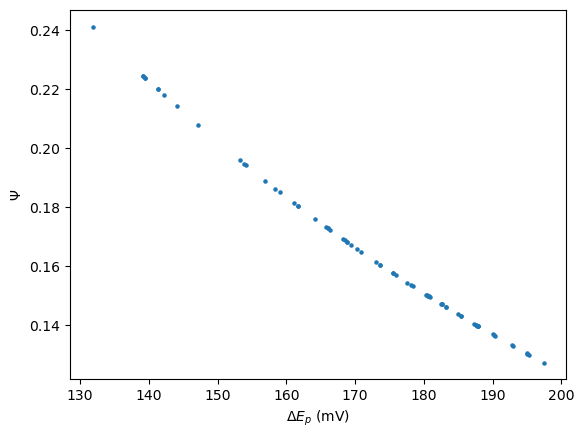

CV_K1 saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Slope: 0.00016624807865935857


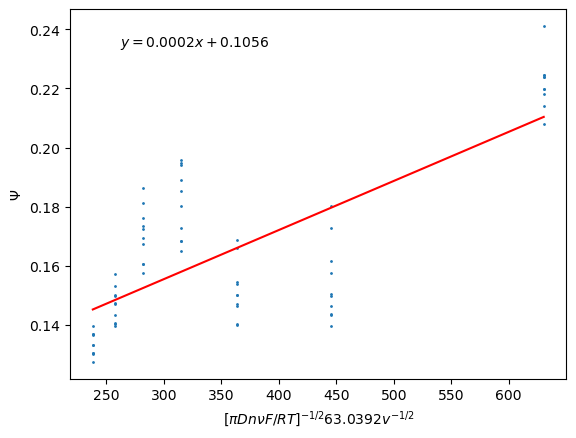

CV_K2 saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
DelE_mV1:  [102.32543945 102.38647461 102.20336914  99.94506836  75.4699707
  70.67871094  68.11523438  68.20678711  68.20678711  65.67382812
  82.7331543   80.32226562  80.26123047  80.26123047  77.81982422
  77.8503418   77.88085938  77.81982422  75.40893555  77.8503418
  89.81323242  89.84375     87.40234375  87.52441406  84.99145508
  84.99145508  85.11352539  85.11352539  85.14404297  85.08300781
  97.13745117  97.10693359  97.13745117  97.10693359  97.10693359
  97.13745117  94.66552734  94.63500977  94.60449219  92.25463867
 101.89819336  99.39575195  99.36523438  99.57885742  99.51782227
  99.51782227  96.98486328  96.9543457   96.92382812  96.98486328
  99.36523438  99.42626953 101.8371582  101.74560547 101.80664062
 101.8371582   99.39575195  99.27368164  99.36523438  99.27368164
 101.5625     104.00390625 104.09545898 104.12597656 101.62353516
 101.65405273 104.12597656 101.6

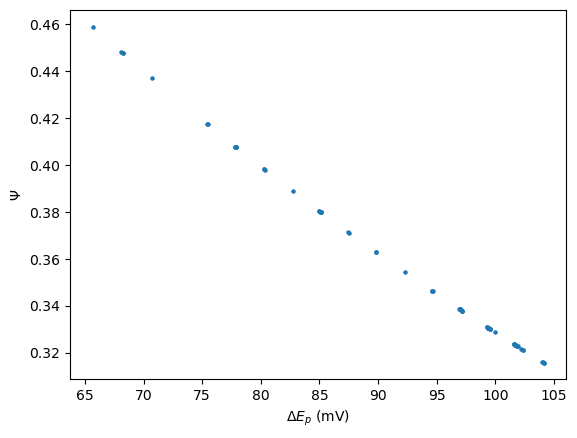

CV_K1 saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Slope: 0.002079782885498285


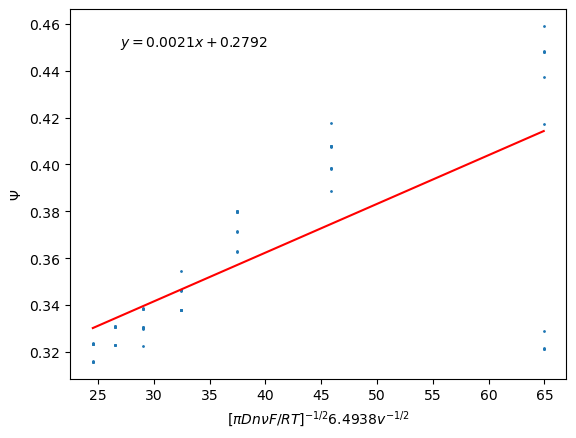

CV_K2 saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
DelE_mV2:  [155.79223633 158.26416016 158.32519531 153.47290039 151.03149414
 148.65112305 143.67675781 141.3269043  141.35742188 138.97705078
 184.87548828 187.2253418  187.2253418  187.71362305 190.1550293
 190.1550293  192.6574707  190.1550293  190.12451172 187.34741211
 209.56420898 214.35546875 219.29931641 219.29931641 224.18212891
 224.18212891 226.68457031 224.24316406 219.29931641 219.4519043
 226.53198242 226.44042969 229.03442383 231.38427734 233.76464844
 238.70849609 238.67797852 238.73901367 238.80004883 238.73901367
 248.87084961 248.90136719 248.93188477 248.93188477 248.90136719
 248.90136719 248.93188477 248.96240234 248.93188477 246.52099609]


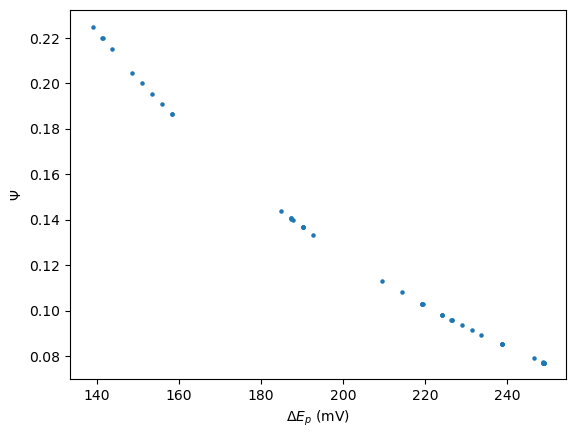

CV_K1 saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Slope: 0.0025665805777777967


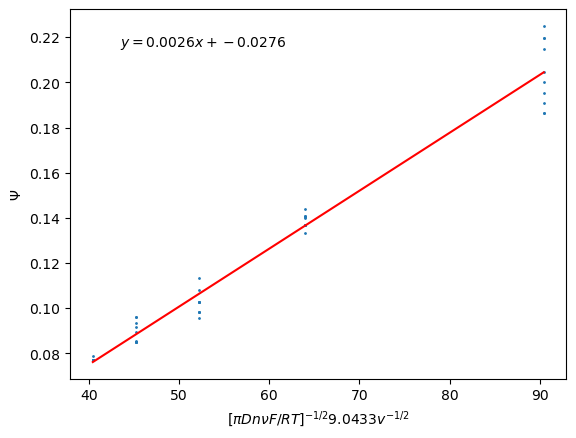

CV_K2 saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
k: [0.00016624807865935857, 0.002079782885498285, 0.0025665805777777967]


In [13]:
## (Function 4)Rate constant module
# Input calculate parameter

a = 0.5
n = [1, 1, 1]
D = [2.057956336878893e-06, 0.0001939368414955827, 0.0001]

# n = [1]
# D = [8e-06]
T = 298.15  # 25 degrees Celsius in Kelvin

# ==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Start:", formatted_time)

# Constant numbers that don't change
F = 96485.33212
R = 8.314462618

k_list = []
for i in range(len(n)):
    DelE = peak_info[f'DelE0{i}']
    Scan_Rate = peak_info[f'Scan_Rate{i}']
    Scan_Rate_V = np.array(Scan_Rate) / 1000
    DelE_mV = np.array(DelE) * 1000
    print(f"DelE_mV{i}: ", DelE_mV)
    
    # Define the lambda function, passing the correct n value
    fai_lambda = lambda DelEi: 2.18 * ((a / math.pi) ** 0.5) * math.exp(-((a ** 2 * F) / (R * T)) * n[i] * DelEi)

    # Apply the lambda function to the list of DelE values
    fai = list(map(fai_lambda, DelE))
    
    # Plotting the results
    plt.figure()
    plt.scatter(DelE_mV, fai, s=5)
    plt.xlabel('$\Delta E_p$ (mV)')
    plt.ylabel('$\Psi$')
    # Save as high-resolution PNG and Vector PDF
    output_name = 'CV_K1'
    output_path = result_path
    os.makedirs(output_path, exist_ok=True)
    output_file = os.path.join(output_path, output_name + '.png')  # For raster format
    plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
    # plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
    plt.show()
    print(f"{output_name} saved in {result_path}")
    
    # Calculate the term [πDnF/RT]^{-1/2}
    term = ((math.pi * D[i] * n[i] * F) / (R * T))**(-1/2)
    term4f = f'{term:.4f}'
    # Calculate x-axis values
    x_value = term * (Scan_Rate_V**(-1/2))
    # Perform linear regression
    slope, intercept = np.polyfit(x_value, fai, 1)
    
    # Plot fai against the term multiplied by v^(-1/2)
    plt.figure()
    plt.scatter(x_value,fai, s=1)
    # Add linear regression line to the plot
    plt.plot(x_value, slope * np.array(x_value) + intercept, color='red')
    # Display the equation of the linear regression line on the plot
    equation = f"$y = {slope:.4f}x + {intercept:.4f}$"
    plt.text(0.1, 0.9, equation, transform=plt.gca().transAxes)
    plt.xlabel('$[πDnνF/RT]^{-1/2}   $' + str(term4f) + '$v^{-1/2}$')
    plt.ylabel('$\Psi$')
    # Display the slope
    print("Slope:", slope)
    k_list.append(slope)
    
    # Save as high-resolution PNG and Vector PDF
    output_name = 'CV_K2'
    output_path = result_path
    os.makedirs(output_path, exist_ok=True)
    output_file = os.path.join(output_path, output_name + '.png')  # For raster format
    plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
    # plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
    plt.show()
    print(f"{output_name} saved in {result_path}")
    
print('k:', k_list )

In [26]:
def special_log(a_list):
    a_list_special_log = np.zeros_like(a_list)  # Initialize log array with zeros

    for idx, value in enumerate(a_list):
        if value > 0:
            a_list_special_log[idx] = np.log10(value)
        elif value < 0:
            a_list_special_log[idx] = np.log10(-value)
        else:  # value == 0
            a_list_special_log[idx] = 0

    return a_list_special_log


def special_ln(a_list):
    a_list_special_ln = np.zeros_like(a_list)  # Initialize log array with zeros

    for idx, value in enumerate(a_list):
        if value > 0:
            a_list_special_ln[idx] = np.log(value)
        elif value < 0:
            a_list_special_ln[idx] = np.log(-value)
        else:  # value == 0
            a_list_special_ln[idx] = 0

    return a_list_special_ln

Electrode Surface Area: 0.07068583470577035
Start: 2024-09-24 17:01:15
GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_10mVs
0.23193359375


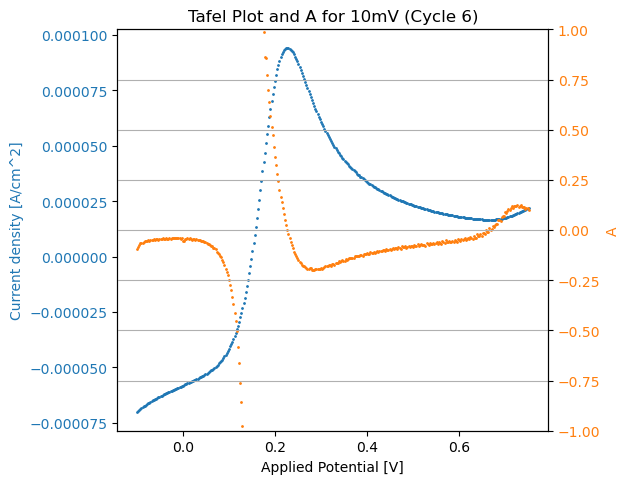

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_20mVs
0.24163818359375


C:\Software\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1240: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
C:\Software\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1241: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
C:\Software\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
C:\Software\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1248: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


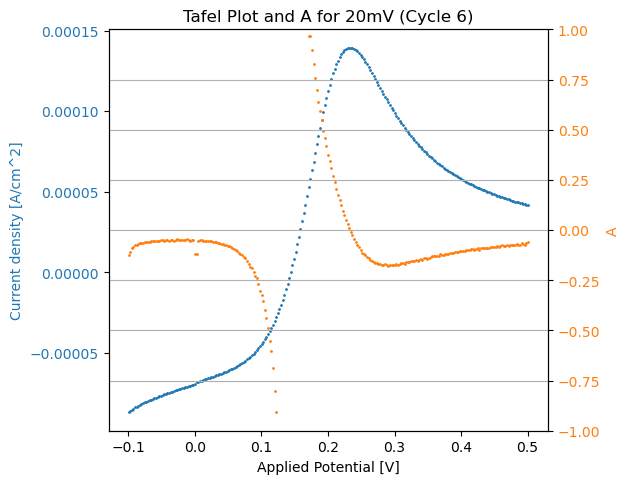

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_50mVs
0.24884033203125


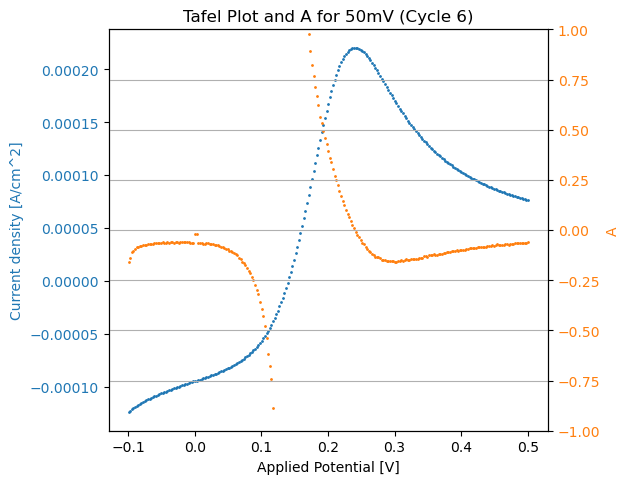

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_100mVs
0.256134033203125


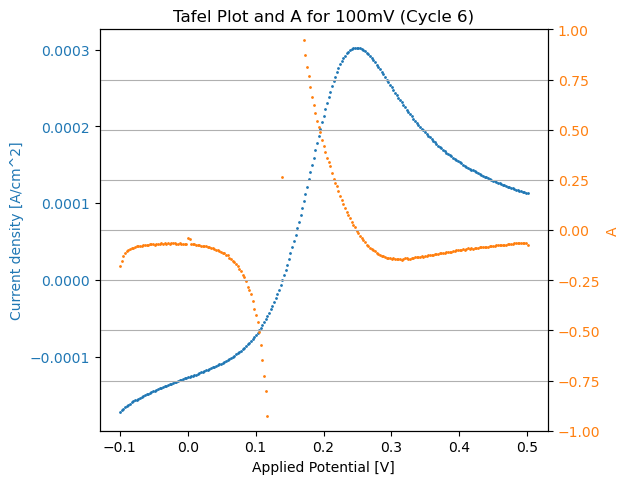

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_150mVs
0.2584228515625


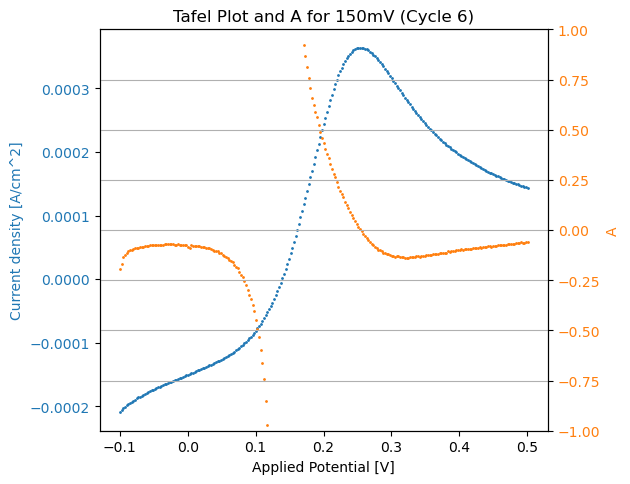

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_200mVs


IndexError: list index out of range

In [27]:
## (Function 5)5.1 Transfer Coefficient Calculate module(method 1)
# Input calculate parameter
cycle = 6 # which cycle you want to see
# Diameter in cm
n = 1
T = 298.15
electrode_dia = 0.30 # electorde diameter in cm 
A_Real = np.pi * (electrode_dia/2)**2
print('Electrode Surface Area:',A_Real)
Which_Current_Peak = 1

# ==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Start:", formatted_time)
# constant number don't change (not input value!!)
F = 96485.33212
R = 8.314462618


for i, var_name in enumerate(data_list):
        df = globals()[var_name]
        print(var_name)
        scan_rate = Search_scan_rate(var_name)
        name = str(scan_rate) + "mV"

        print(peak_info[f'Ea0'][len(cycle_range)*i+(cycle-cycle_range[0])])
        cycle_df = df[df['Scan'] == cycle]
        Ui = cycle_df['WE(1).Potential (V)']
        Ii = cycle_df['WE(1).Current (A)']
        Ui = np.array(Ui)
        Ii = np.array(Ii)
        Ji = Ii/A_Real

        # Separate top and bottom
        upperU, lowerU, upperJ, lowerJ = separater(Ui, Ji, min(Ui), max(Ui))

        # Apply Gaussian filter (optional)
        apply_gaussian_filter = False  # Set to True to apply the filter, False to not apply the filter

        if apply_gaussian_filter:
            smoothed_upperJ = gaussian_filter(upperJ, sigma=1)
            smoothed_lowerJ = gaussian_filter(lowerJ, sigma=1)
        else:
            smoothed_upperJ = upperJ
            smoothed_lowerJ = lowerJ
            
        logJ_upper = special_log(smoothed_upperJ)
        dlogJ_dU = np.gradient(logJ_upper, upperU)
        dU_dlogJ = np.gradient(upperU, logJ_upper)
        Tafel_slope = 1 / dlogJ_dU
        # Calculate the transfer coefficient (alpha)
        alpha = (2.303 * R * T) / (Tafel_slope * n * F)
        
#         # Create a figure with dual x-axes
#         fig, ax1 = plt.subplots()

#         ax1.set_xlabel('log(current density) [log(A/cm^2)]', color=colors[0])
#         ax1.set_ylabel('Potential [V]')
#         ax1.scatter(logJ_upper, upperU, s=1, color=colors[0])
#         ax1.tick_params(axis='x', labelcolor=colors[0])

#         ax2 = ax1.twiny()  # instantiate a second axes that shares the same y-axis
#         ax2.set_xlabel('Transfer coefficient', color=colors[1])
#         ax2.scatter(alpha, upperU, s=1, color=colors[1])
#         ax2.set_xlim([-1, 1])  # Limit x-axis for transfer coefficient between -1 and 1
#         ax2.tick_params(axis='x', labelcolor=colors[1])

#         fig.tight_layout()  # otherwise the right y-label is slightly clipped
#         plt.title(f'Tafel Plot and Tafel Slope for {name} (Cycle {cycle})')
#         plt.grid(True)
#         plt.show()
# #         Create a figure with dual y-axes
#         fig, ax1 = plt.subplots()
#         ax1.set_xlabel('log(current density) [log(A/cm^2)]')
#         ax1.set_ylabel('Applied Potential [V]', color=colors[0])
#         ax1.scatter(logJ_upper , upperU, s=1, color=colors[0])
#         ax1.tick_params(axis='y', labelcolor=colors[0])

#         ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
#         ax2.set_ylabel('Transfer coefficient', color=colors[1])  # we already handled the x-label with ax1
#         ax2.scatter(logJ_upper, alpha, s=1, color=colors[1])
#         ax2.set_ylim([-1, 1])  # Limit y-axis for transfer coefficient between -1 and 1
#         ax2.tick_params(axis='y', labelcolor=colors[1])

#         fig.tight_layout()  # otherwise the right y-label is slightly clipped
#         plt.title(f'Tafel Plot and Derivative for {name} (Cycle {cycle})')
#         plt.grid(True)
#         plt.show()

        
        # Create a figure with dual y-axes
        fig, ax1 = plt.subplots()
        ax1.set_xlabel('Applied Potential [V]')
        ax1.set_ylabel('Current density [A/cm^2]', color=colors[0])
        ax1.scatter(upperU , smoothed_upperJ, s=1, color=colors[0])
        ax1.tick_params(axis='y', labelcolor=colors[0])

        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
        ax2.set_ylabel('\u0391', color=colors[1])  # we already handled the x-label with ax1
        ax2.scatter(upperU, alpha, s=1, color=colors[1])
        ax2.set_ylim([-1, 1])  # Limit y-axis for transfer coefficient between -1 and 1
        ax2.tick_params(axis='y', labelcolor=colors[1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.title(f'Tafel Plot and \u0391 for {name} (Cycle {cycle})')
        plt.grid(True)
        plt.show()
        

In [9]:
print(peak_info[f'Ea0'][len(cycle_range)*i+(cycle-cycle_range[0])])

0.23663330078125


Start: 2024-09-03 16:20:26
GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_10mVs


C:\Users\Grant Xue\AppData\Local\Temp\ipykernel_22276\1579922220.py:43: RuntimeWarning: divide by zero encountered in divide
  I_term = (I_Peak**2)/(I_Peak-smoothed_upperI)


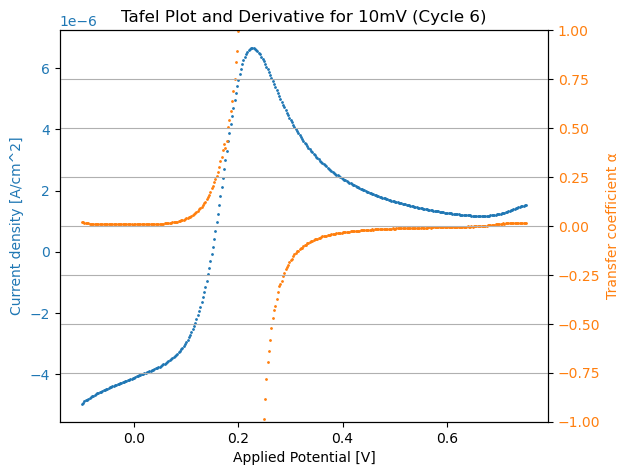

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_20mVs


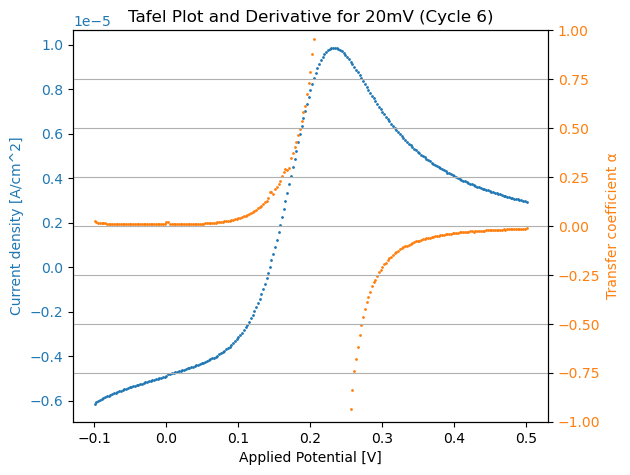

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_50mVs


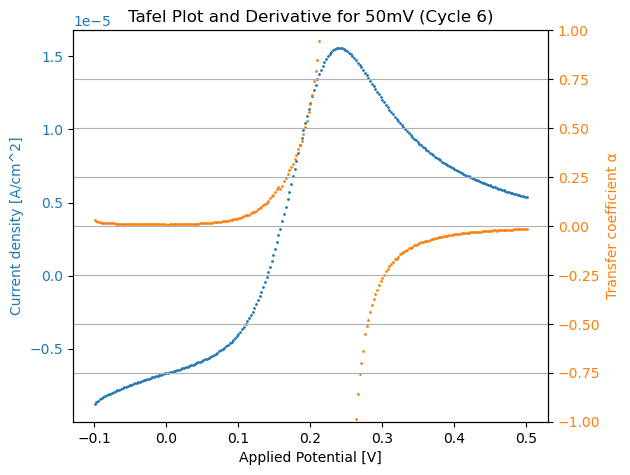

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_100mVs


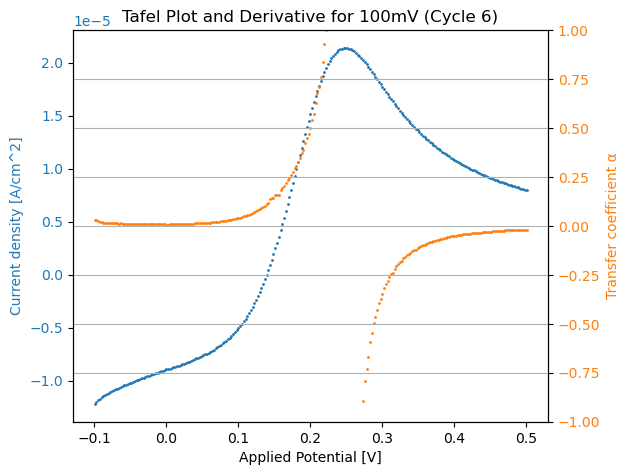

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_150mVs


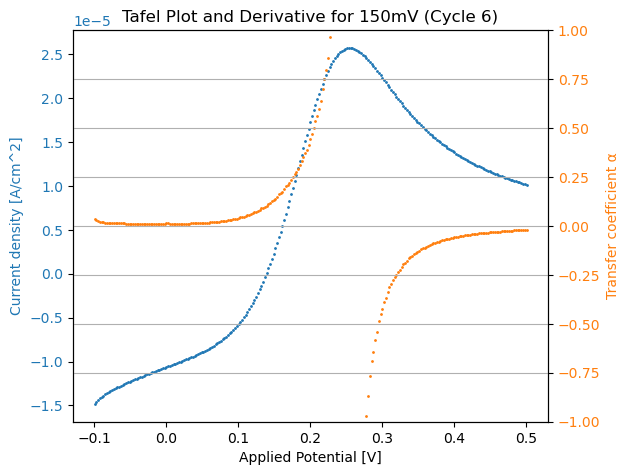

GC_P_KNO3_K3FeCN6_-0.1to0.75_2mM_200mVs


C:\Software\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1248: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


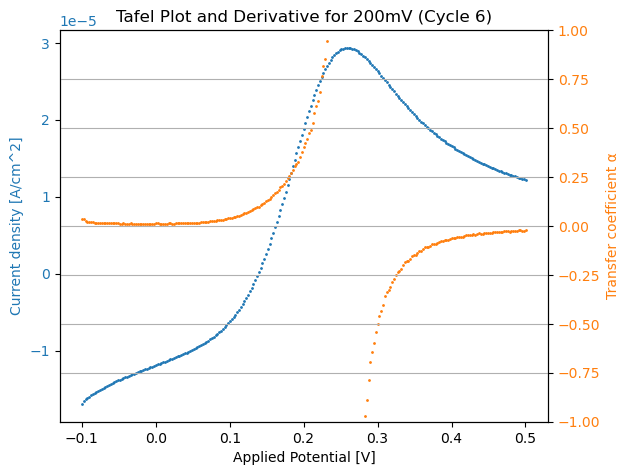

In [33]:
## (Function 5)5.2 Transfer Coefficient Calculate module(method 2)

# ==============================
now = datetime.now()
formatted_time = now.strftime("%Y-%m-%d %H:%M:%S")
print("Start:", formatted_time)


for i, var_name in enumerate(data_list):
        df = globals()[var_name]
        print(var_name)
        scan_rate = Search_scan_rate(var_name)
        name = str(scan_rate) + "mV"

#         print(peak_info[f'Ea0'][len(cycle_range)*i+(cycle-cycle_range[0])])
        cycle_df = df[df['Scan'] == cycle]
        Ui = cycle_df['WE(1).Potential (V)']
        Ii = cycle_df['WE(1).Current (A)']
        Ui = np.array(Ui)
        Ii = np.array(Ii)
        Ji = Ii/A_Real
        Ji = Ii
        # Separate top and bottom
        upperU, lowerU, upperI, lowerI = separater(Ui, Ii, min(Ui), max(Ui))

        # Apply Gaussian filter (optional)
        apply_gaussian_filter = False  # Set to True to apply the filter, False to not apply the filter

        if apply_gaussian_filter:
            smoothed_upperI = gaussian_filter(upperI, sigma=1)
            smoothed_lowerI = gaussian_filter(lowerI, sigma=1)
        else:
            smoothed_upperI = upperI
            smoothed_lowerI = lowerI
            
        smoothed_upperI = np.array(smoothed_upperI)
        smoothed_lowerI = np.array(smoothed_upperI)
        
        upperU = np.array(upperU)
        lowerU = np.array(lowerU)
        
        I_Peak = peak_info[f'Ia{Which_Current_Peak-1}'][i*len(cycle_range) + (cycle-min(cycle_range))]
        I_term = (I_Peak**2)/(I_Peak-smoothed_upperI)
        lnI_term = special_ln(I_term)
        upperO = (F/(R * T)) * upperU
        
        dlnI_term_dU = np.gradient(lnI_term, upperU)
        alpha = (1/2)*((R * T) / F) * dlnI_term_dU
        
#         dlnI_term_dO = np.gradient(lnI_term, upperO)
#         alpha = (1/2)*dlnI_term_dO
        
        
        #Create a figure with dual y-axes
        fig, ax1 = plt.subplots()
        ax1.set_xlabel('Applied Potential [V]')
        ax1.set_ylabel('Current density [A/cm^2]', color=colors[0])
        ax1.scatter(upperU , smoothed_upperI, s=1, color=colors[0])
        ax1.tick_params(axis='y', labelcolor=colors[0])

        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
        ax2.set_ylabel('Transfer coefficient \u03B1', color=colors[1])  # we already handled the x-label with ax1
        ax2.scatter(upperU, alpha, s=1, color=colors[1])
        ax2.set_ylim([-1, 1])  # Limit y-axis for transfer coefficient between -1 and 1
        ax2.tick_params(axis='y', labelcolor=colors[1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.title(f'Tafel Plot and Derivative for {name} (Cycle {cycle})')
        plt.grid(True)
        plt.show()

        
#         # Create a figure with dual y-axes
#         fig, ax1 = plt.subplots()
#         ax1.set_xlabel('Applied Potential [V]')
#         ax1.set_ylabel('log(current density) [log(A/cm^2)]', color=colors[0])
#         ax1.scatter(upperU, logJ_upper, s=1, color=colors[0])
#         ax1.tick_params(axis='y', labelcolor=colors[0])

#         ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
#         ax2.set_ylabel('d(log(current density))/d(Applied Potential) [1/V]', color=colors[1])  # we already handled the x-label with ax1
#         ax2.scatter(upperU, dlogJ_dU, s=1, color=colors[1])
#         ax2.tick_params(axis='y', labelcolor=colors[1])

#         fig.tight_layout()  # otherwise the right y-label is slightly clipped
#         plt.title(f'Tafel Plot and Derivative for {name} (Cycle {cycle})')
#         plt.grid(True)
#         plt.show()

In [31]:
print(type(upperU))
print(len(upperU))
print(type(lnI_term))
print(len(lnI_term))

<class 'numpy.ndarray'>
350
<class 'numpy.ndarray'>
350


Series([], Name: WE(1).Potential (V), dtype: float64)
